In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [2]:
model_data = pd.read_csv("../data/processed/model_data.csv")

model_data.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,result_label,home_recent_win_rate,home_recent_avg_goals_scored,home_recent_avg_goals_conceded,away_recent_win_rate,away_recent_avg_goals_scored,away_recent_avg_goals_conceded,win_rate_difference,attack_difference,defense_difference
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,Draw,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,Home Win,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,Home Win,1,0.000000,1.000000,2.000000,0.500000,2.000000,1.000000,-0.5,-1.000000,1.000000
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,Draw,0,0.333333,1.666667,1.333333,0.333333,1.333333,1.666667,0.0,0.333333,-0.333333
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,Home Win,1,0.250000,1.500000,1.750000,0.250000,1.750000,1.500000,0.0,-0.250000,0.250000


In [3]:
model_data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'result', 'result_label',
       'home_recent_win_rate', 'home_recent_avg_goals_scored',
       'home_recent_avg_goals_conceded', 'away_recent_win_rate',
       'away_recent_avg_goals_scored', 'away_recent_avg_goals_conceded',
       'win_rate_difference', 'attack_difference', 'defense_difference'],
      dtype='object')

In [4]:
features = [
    "home_recent_win_rate",
    "home_recent_avg_goals_scored",
    "home_recent_avg_goals_conceded",
    "away_recent_win_rate",
    "away_recent_avg_goals_scored",
    "away_recent_avg_goals_conceded",
    "win_rate_difference",
    "attack_difference",
    "defense_difference",
    "neutral"
]

target = "result_label"

In [5]:
X = model_data[features]
y = model_data[target]

In [6]:
X.isnull().sum()

home_recent_win_rate              0
home_recent_avg_goals_scored      0
home_recent_avg_goals_conceded    0
away_recent_win_rate              0
away_recent_avg_goals_scored      0
away_recent_avg_goals_conceded    0
win_rate_difference               0
attack_difference                 0
defense_difference                0
neutral                           0
dtype: int64

In [7]:
X = X.fillna(0)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
log_predictions = log_model.predict(X_test)

In [11]:
log_accuracy = accuracy_score(y_test, log_predictions)

log_accuracy

0.5324167001204335

In [12]:
print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

          -1       0.48      0.37      0.42      2809
           0       0.00      0.00      0.00      2269
           1       0.55      0.87      0.67      4886

    accuracy                           0.53      9964
   macro avg       0.34      0.41      0.36      9964
weighted avg       0.40      0.53      0.45      9964



C:\Users\kshit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kshit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kshit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
rf_predictions = rf_model.predict(X_test)

In [15]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_accuracy

0.4793255720594139

In [16]:
print("Logistic Regression Accuracy:", log_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.5324167001204335
Random Forest Accuracy: 0.4793255720594139


In [17]:
confusion_matrix(y_test, rf_predictions)

array([[1083,  357, 1369],
       [ 583,  319, 1367],
       [ 873,  639, 3374]], dtype=int64)

In [18]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
7,attack_difference,0.140434
8,defense_difference,0.137516
1,home_recent_avg_goals_scored,0.137016
4,away_recent_avg_goals_scored,0.135203
2,home_recent_avg_goals_conceded,0.129030
5,away_recent_avg_goals_conceded,0.127147
6,win_rate_difference,0.066891
0,home_recent_win_rate,0.052104
3,away_recent_win_rate,0.051867
9,neutral,0.022794


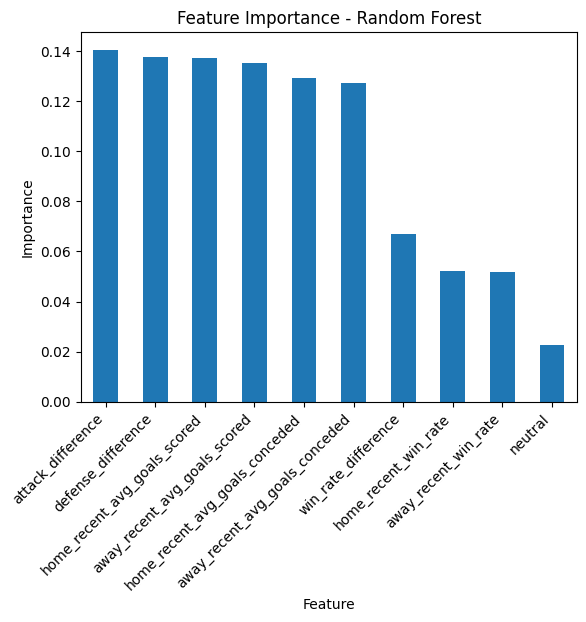

In [19]:
import matplotlib.pyplot as plt

feature_importance.plot(
    kind="bar",
    x="feature",
    y="importance",
    legend=False
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

In [20]:
joblib.dump(rf_model, "../models/world_cup_predictor_model.pkl")

['../models/world_cup_predictor_model.pkl']

In [21]:
joblib.dump(features, "../models/model_features.pkl")

['../models/model_features.pkl']

In [22]:
sample_match = pd.DataFrame([{
    "home_recent_win_rate": 0.60,
    "home_recent_avg_goals_scored": 2.0,
    "home_recent_avg_goals_conceded": 1.0,
    "away_recent_win_rate": 0.40,
    "away_recent_avg_goals_scored": 1.4,
    "away_recent_avg_goals_conceded": 1.2,
    "win_rate_difference": 0.20,
    "attack_difference": 0.60,
    "defense_difference": -0.20,
    "neutral": True
}])

In [23]:
rf_model.predict(sample_match)

array([1], dtype=int64)

In [24]:
rf_model.predict_proba(sample_match)

array([[0.12666667, 0.432     , 0.44133333]])

In [25]:
probabilities = rf_model.predict_proba(sample_match)[0]

prediction_output = pd.DataFrame({
    "Result": rf_model.classes_,
    "Probability": probabilities
})

prediction_output

,Result,Probability
0,-1,0.126667
1,0,0.432000
2,1,0.441333
